<a href="https://colab.research.google.com/github/senchiao/HRRR_plots/blob/main/surface_stn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install metpy cartopy
from datetime import datetime, timedelta
from io import StringIO
from urllib.request import urlopen

from metpy.io import metar
from metpy.plots import declarative
from metpy.units import units
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 22.9 MB/s eta 0:00:00


In [5]:
date = datetime(2026, 8, 5, 10)

# Remote Access - Archive Data Read with pandas from Iowa State Archive,
# note differences from METAR files
dt = timedelta(minutes=15)
sdate = date - dt
edate = date + dt
data_url = ('http://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?'
            'data=all&tz=Etc/UTC&format=comma&latlon=yes&'
            f'year1={sdate.year}&month1={sdate.month}&day1={sdate.day}'
            f'&hour1={sdate.hour}&minute1={sdate.minute}&'
            f'year2={edate.year}&month2={edate.month}&day2={edate.day}'
            f'&hour2={edate.hour}&minute2={edate.minute}')
data = pd.read_csv(data_url, skiprows=5, na_values=['M'],
                   low_memory=False).replace('T', 0.00001).groupby('station').tail(1)
df = metar.parse_metar_file(StringIO('\n'.join(val for val in data.metar)),
                            year=date.year, month=date.month)
df['date_time'] = date

df['tmpf'] = (df.air_temperature.values * units.degC).to('degF')
df['dwpf'] = (df.dew_point_temperature.values * units.degC).to('degF')

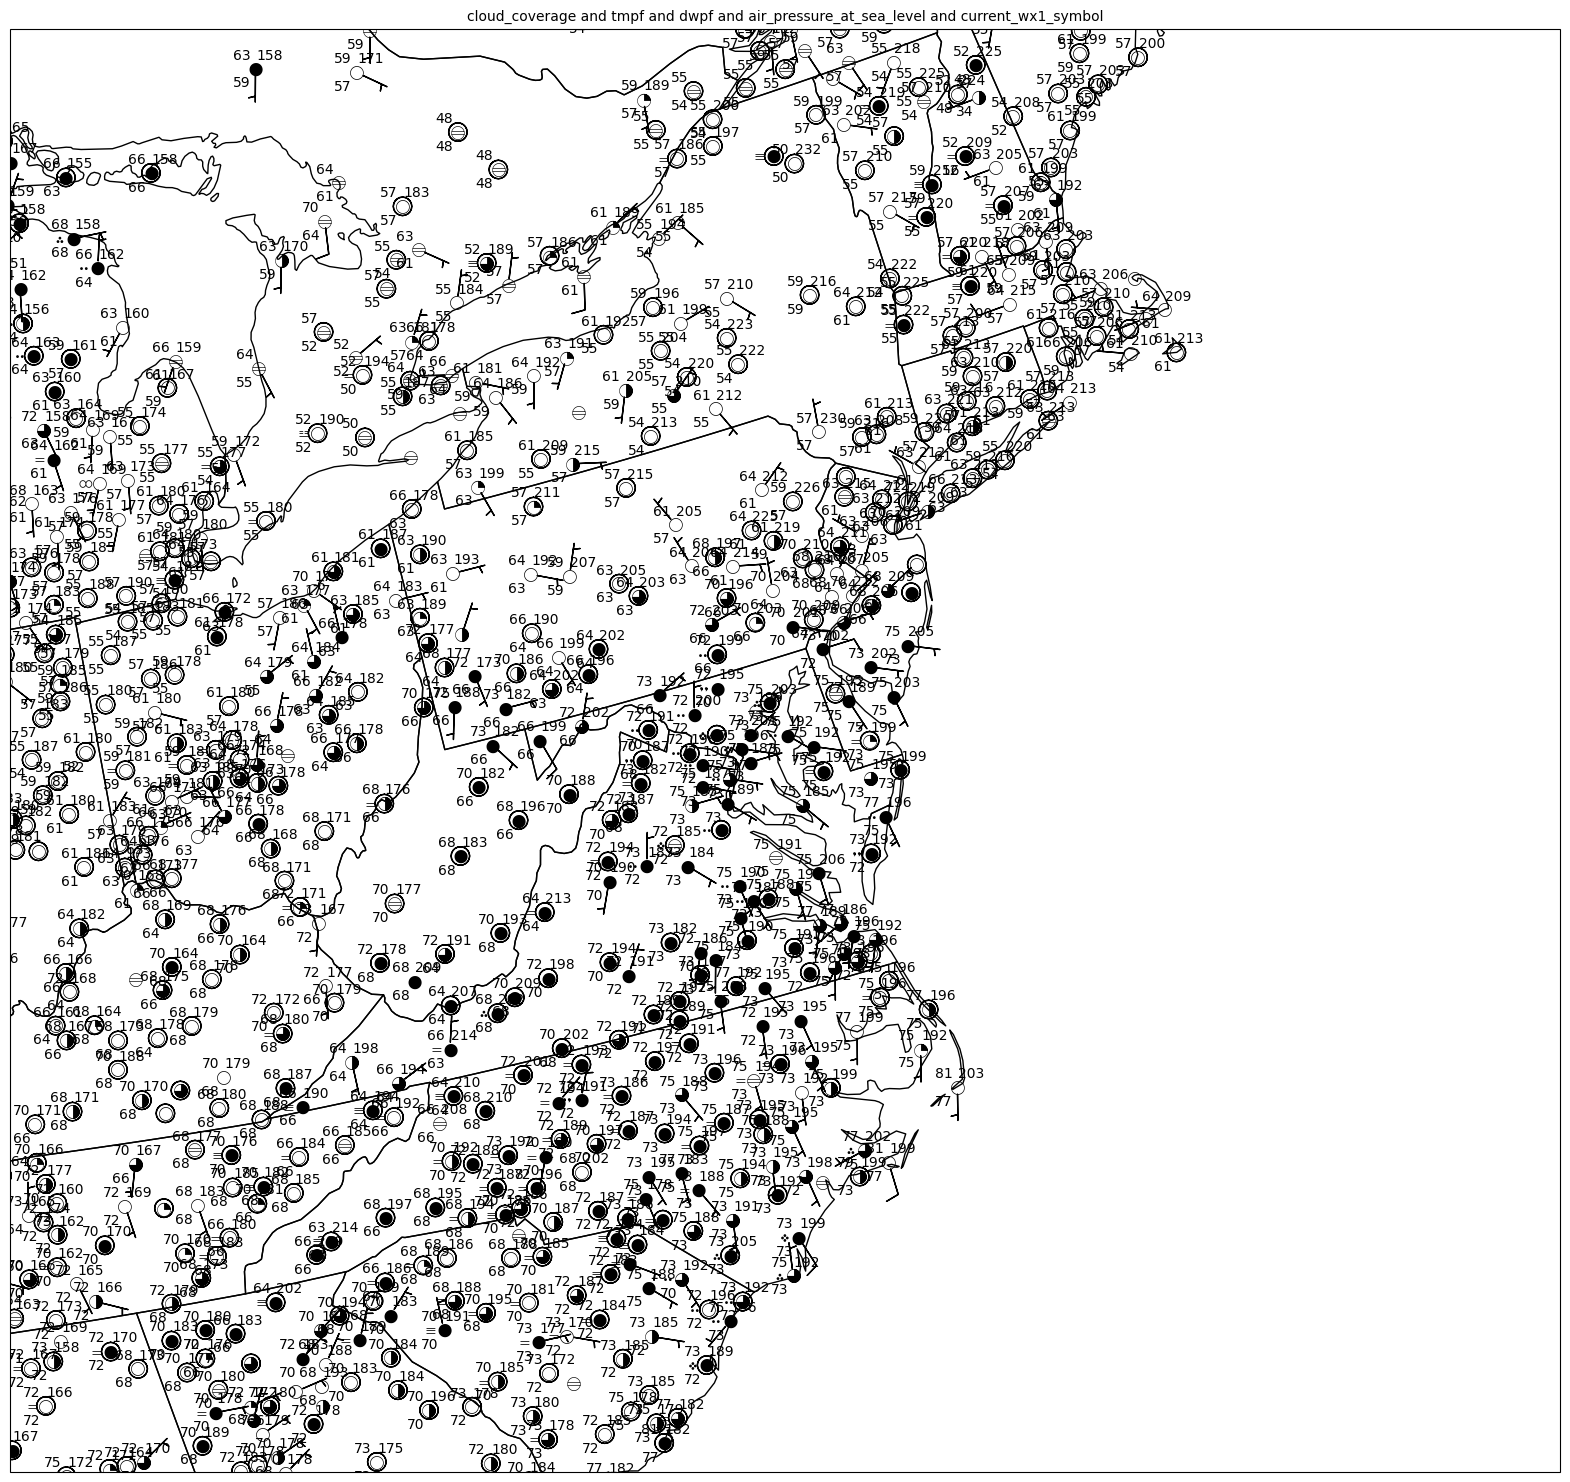

In [28]:
mslp_formatter = lambda v: format(v*10, '.0f')[-3:]

# Plot desired data
obs = declarative.PlotObs()
obs.data = df
obs.time = date
obs.time_window = timedelta(minutes=15)
obs.level = None
obs.fields = ['cloud_coverage', 'tmpf', 'dwpf',
              'air_pressure_at_sea_level', 'current_wx1_symbol']
obs.locations = ['C', 'NW', 'SW', 'NE', 'W']
obs.formats = ['sky_cover', None, None, mslp_formatter, 'current_weather']
obs.reduce_points = 0.15
obs.vector_field = ['eastward_wind', 'northward_wind']

# this part is not working
pc = declarative.PanelContainer()
mslp_contour = declarative.ContourPlot()
mslp_contour.data = df
mslp_contour.field = 'air_pressure_at_sea_level'
mslp_contour.level = list(range(980, 1041, 2)) * units.hPa
mslp_contour.linewidth = 1
mslp_contour.linecolor = 'red'
#

# Panel for plot with Map features
panel = declarative.MapPanel()
panel.layout = (1, 1, 1)
panel.projection = 'lcc'
panel.area = 'DC'
panel.layers = ['states']
panel.plots = [obs]

# Bringing it all together

pc.size = (20, 20)

pc.panels = [panel]

pc.show()